# Fase 1 — Modelo Predictivo: Severidad de Accidentes de Tránsito

**Proyecto Integrador — Modelos y Simulación de Sistemas I (2026-2)**
**Docente:** Andrés Felipe Parra

**Equipo:** 

Carolina Arboleda Guzmán

Carol Juliana Henao Causil

## 1. Introducción

**Problema seleccionado:** predecir la severidad de un accidente de tránsito a partir de las
características del conductor, el vehículo, la vía, las condiciones ambientales y de la propia
víctima (casualty) involucrada, utilizando datos reales de accidentes registrados en Addis
Abeba, Etiopía.

**Objetivo del modelo:** construir un modelo capaz de clasificar un accidente según su nivel
de severidad, de manera que —en fases posteriores del proyecto— pueda utilizarse como
insumo para priorizar la atención de accidentes o identificar patrones de riesgo.

**Tipo de problema:** clasificación **multiclase** (3 clases).

**Variable objetivo:** `Accident_severity`, con tres posibles valores:
- `Slight Injury` (herida leve)
- `Serious Injury` (herida grave)
- `Fatal injury` (fatal)

**Fuente de los datos:** conjunto de datos público de accidentes de tránsito de Addis Abeba
(Etiopía), distribuido en formato CSV (`train.csv`), con 8.210 observaciones (filas) y 33
variables originales, cada una correspondiente a una víctima (*casualty*) involucrada en un
accidente.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, f1_score, accuracy_score)
import joblib

RANDOM_STATE = 42  # semilla fija para reproducibilidad en todo el notebook

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 40)

## 2. Descripción del conjunto de datos

Cada fila del conjunto de datos representa una **víctima (casualty)** dentro de un accidente
de tránsito, no el accidente como tal (un mismo accidente puede tener varias filas si hubo
varias víctimas). Las variables describen: el momento del accidente, el conductor, el
vehículo, la vía, las condiciones ambientales, el tipo de colisión y la persona afectada.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                            ConfusionMatrixDisplay, f1_score, accuracy_score)
import joblib

RANDOM_STATE = 42  # semilla fija para reproducibilidad en todo el notebook

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 40)

In [4]:

df = pd.read_csv("../train.csv")

df.head()

,Num,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,1,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,NaN,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,2,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,3,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,No defect,Recreational areas,other,NaN,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,No defect,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,5,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,No defect,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8210 entries, 0 to 8209
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Num                          8210 non-null   int64
 1   Time                         8210 non-null   str  
 2   Day_of_week                  8210 non-null   str  
 3   Age_band_of_driver           8210 non-null   str  
 4   Sex_of_driver                8210 non-null   str  
 5   Educational_level            7734 non-null   str  
 6   Vehicle_driver_relation      7870 non-null   str  
 7   Driving_experience           7665 non-null   str  
 8   Type_of_vehicle              7558 non-null   str  
 9   Owner_of_vehicle             7889 non-null   str  
 10  Service_year_of_vehicle      5505 non-null   str  
 11  Defect_of_vehicle            5225 non-null   str  
 12  Area_accident_occured        8050 non-null   str  
 13  Lanes_or_Medians             7943 non-null   str  
 14  Roa

**Variable objetivo:** `Accident_severity` — nivel de severidad del accidente asociado a esa
víctima (leve, grave o fatal).

**Tipos de variables:** la gran mayoría de las variables son **categóricas** (texto), con
excepción de `Num` (identificador), `Number_of_vehicles_involved` y `Number_of_casualties`,
que son numéricas discretas, y `Time`, que es una marca de hora (no fecha) que transformaremos
más adelante en una variable numérica/categórica útil.

**Limitaciones del conjunto de datos:**
- Varias variables tienen un porcentaje alto de valores faltantes (hasta ~36%), lo que exige
  una estrategia de imputación cuidadosa en lugar de eliminar observaciones.
- El desbalance de clases es fuerte: la mayoría de los registros corresponden a heridas leves
  y muy pocos a accidentes fatales, lo cual afecta la elección de la métrica de evaluación y
  del modelo.
- Al estar la unidad de análisis a nivel de víctima y no de accidente, existen variables
  (por ejemplo `Casualty_severity`) que describen directamente el resultado de esa víctima y
  que representan un riesgo de fuga de información si se usan como predictoras (se analiza en
  la sección 4).

## 3. Exploración de los datos (EDA)

### 3.1 Distribución de la variable objetivo


                   conteo      %
Accident_severity               
Slight Injury        7082  86.26
Serious Injury       1046  12.74
Fatal injury           82   1.00


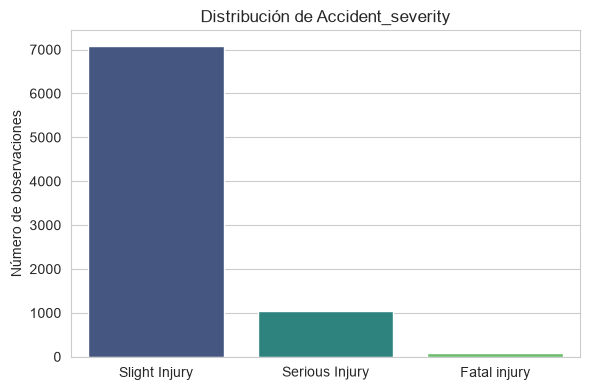

In [6]:
target_counts = df["Accident_severity"].value_counts()
target_pct = df["Accident_severity"].value_counts(normalize=True) * 100
print(pd.concat([target_counts, target_pct.round(2)], axis=1, keys=["conteo", "%"]))

plt.figure(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, hue=target_counts.index,
            palette="viridis", legend=False)
plt.title("Distribución de Accident_severity")
plt.ylabel("Número de observaciones")
plt.xlabel("")
plt.tight_layout()
plt.show()

El conjunto de datos está **fuertemente desbalanceado**: cerca del 86% de las observaciones
son heridas leves, ~12.7% graves y apenas ~1% fatales. Esto tiene dos implicaciones directas
para el resto del proyecto:
1. La **accuracy** no es una buena métrica por sí sola (un modelo que siempre prediga "Slight
   Injury" tendría ~86% de accuracy sin haber aprendido nada útil).
2. El modelo deberá entrenarse teniendo en cuenta el desbalance (por ejemplo, ponderando las
   clases).


### 3.2 Valores faltantes por variable

In [7]:
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
missing_df = pd.concat([missing, missing_pct], axis=1, keys=["n_faltantes", "%_faltantes"])
missing_df = missing_df[missing_df["n_faltantes"] > 0].sort_values("%_faltantes", ascending=False)
missing_df

,n_faltantes,%_faltantes
Defect_of_vehicle,2985,36.36
Service_year_of_vehicle,2705,32.95
Work_of_casuality,2148,26.16
Fitness_of_casuality,1770,21.56
Type_of_vehicle,652,7.94
Driving_experience,545,6.64
Educational_level,476,5.80
Vehicle_driver_relation,340,4.14
Owner_of_vehicle,321,3.91
Lanes_or_Medians,267,3.25


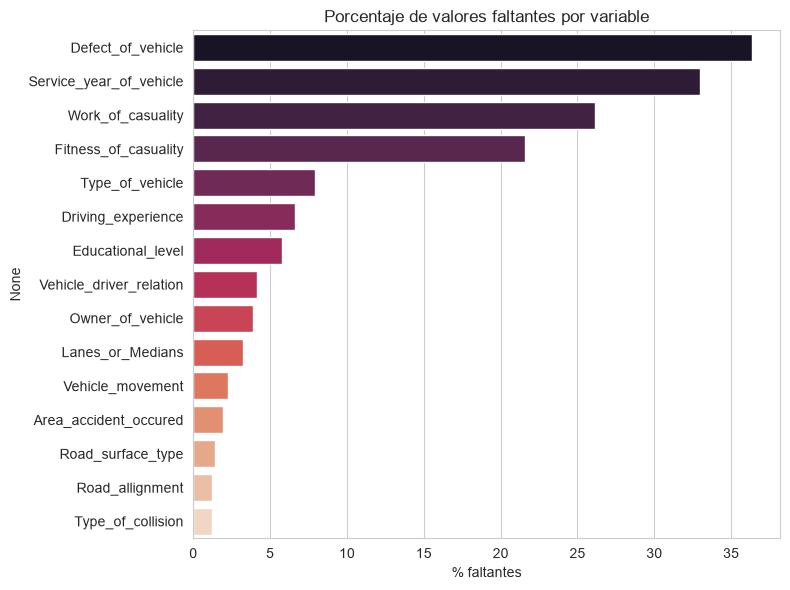

In [8]:
plt.figure(figsize=(8, 6))
sns.barplot(x=missing_df["%_faltantes"], y=missing_df.index, hue=missing_df.index,
            palette="rocket", legend=False)
plt.title("Porcentaje de valores faltantes por variable")
plt.xlabel("% faltantes")
plt.tight_layout()
plt.show()

Se identifican **15 variables predictoras con valores faltantes**, todas categóricas. Algunas
tienen un porcentaje muy bajo (`Road_allignment`, `Type_of_collision`, `Type_of_collision`,
`Road_surface_type`, `Area_accident_occured`, todas entre 1% y 2%, cumpliendo el rango exigido
por el taller), mientras que otras tienen un porcentaje considerable (`Defect_of_vehicle` con
~36%, `Service_year_of_vehicle` con ~33%). Esto se trata en la sección de preparación de datos.


### 3.3 Estadísticas descriptivas

In [9]:
df.describe(include="number")


,Num,Number_of_vehicles_involved,Number_of_casualties
count,8210.000000,8210.000000,8210.000000
mean,4105.500000,2.011571,1.505116
std,2370.167188,0.643748,0.974038
min,1.000000,1.000000,1.000000
25%,2053.250000,2.000000,1.000000
50%,4105.500000,2.000000,1.000000
75%,6157.750000,2.000000,2.000000
max,8210.000000,7.000000,8.000000


In [10]:
df.describe(include="object").T


C:\Users\Carolina\AppData\Local\Temp\ipykernel_7124\3164331651.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
Time,8210,1027,18:00:00,76
Day_of_week,8210,7,Friday,1326
Age_band_of_driver,8210,5,18-30,2728
Sex_of_driver,8210,3,Male,7582
Educational_level,7734,7,Junior high school,5064
Vehicle_driver_relation,7870,4,Employee,6373
Driving_experience,7665,7,5-10yr,2268
Type_of_vehicle,7558,17,Automobile,2130
Owner_of_vehicle,7889,4,Owner,6972
Service_year_of_vehicle,5505,6,Unknown,1838


### 3.4 Relación entre variables predictoras y la variable objetivo

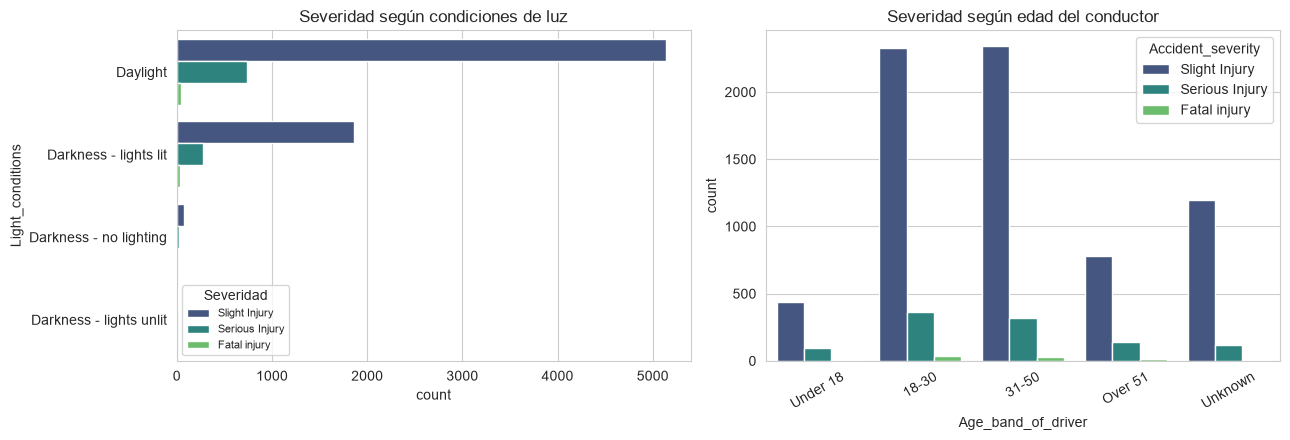

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

order_light = df["Light_conditions"].value_counts().index
sns.countplot(data=df, y="Light_conditions", hue="Accident_severity", order=order_light,
                ax=axes[0], palette="viridis")
axes[0].set_title("Severidad según condiciones de luz")
axes[0].legend(title="Severidad", fontsize=8)

order_age = ["Under 18", "18-30", "31-50", "Over 51", "Unknown"]
order_age = [o for o in order_age if o in df["Age_band_of_driver"].unique()]
sns.countplot(data=df, x="Age_band_of_driver", hue="Accident_severity", order=order_age,
                ax=axes[1], palette="viridis")
axes[1].set_title("Severidad según edad del conductor")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

No se observan diferencias extremas en la *proporción* de severidad entre grupos (el
desbalance de clases domina visualmente todas las categorías), pero sí se aprecian variaciones
sutiles razonables: por ejemplo, la proporción de accidentes graves/fatales tiende a ser
relativamente mayor en condiciones de poca luz (`Darkness - no lighting`) que en luz de día, lo
cual es consistente con la intuición del dominio.


### 3.5 Correlación entre variables numéricas

                             Number_of_vehicles_involved  Number_of_casualties
Number_of_vehicles_involved                     1.000000              0.203409
Number_of_casualties                            0.203409              1.000000


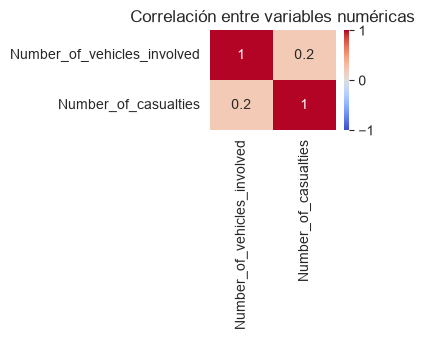

In [12]:
num_cols_eda = ["Number_of_vehicles_involved", "Number_of_casualties"]
corr = df[num_cols_eda].corr()
print(corr)

plt.figure(figsize=(4, 3.5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación entre variables numéricas")
plt.tight_layout()
plt.show()

Solo existen dos variables numéricas originales (`Number_of_vehicles_involved` y
`Number_of_casualties`); su correlación es baja-moderada, por lo que no se identifica
redundancia que justifique eliminar alguna de ellas. El resto de variables son categóricas, por
lo que un análisis de correlación numérica clásico no aplica directamente sobre ellas; su
relación con el objetivo se exploró mediante conteos cruzados (sección 3.4).


## 4. Preparación de los datos

### 4.1 Variables sobre `Time`

`Time` viene como texto (`HH:MM:SS`). Se extrae la hora del día como variable numérica
(`Hour`) y se descarta el texto original, que en su forma cruda tiene demasiadas categorías
únicas (1.027) para ser útil directamente.


In [13]:
df_prep = df.copy()

df_prep["Hour"] = pd.to_datetime(df_prep["Time"], format="%H:%M:%S").dt.hour
df_prep = df_prep.drop(columns=["Time"])

df_prep[["Hour"]].describe()

,Hour
count,8210.000000
mean,13.808526
std,5.253160
min,0.000000
25%,10.000000
50%,15.000000
75%,18.000000
max,23.000000


### 4.2 Eliminación de variables no predictoras o con riesgo de fuga de información

- `Num` es un identificador secuencial de fila; no aporta información predictiva real y se
  elimina.
- `Casualty_severity` describe la severidad sufrida por **esa víctima específica**, que es
  prácticamente el mismo concepto que la variable objetivo (`Accident_severity`) a nivel de
  víctima. Utilizarla como predictora constituiría **fuga de información**, ya que en la
  práctica no se conocería antes de determinar la severidad del accidente. Se elimina como
  predictora (ver sección 5 para la justificación completa).

In [14]:
LEAKAGE_COLS = ["Num", "Casualty_severity"]
df_prep = df_prep.drop(columns=LEAKAGE_COLS)

TARGET = "Accident_severity"
X = df_prep.drop(columns=[TARGET])
y = df_prep[TARGET]

print("Predictoras finales:", X.shape[1])
print(list(X.columns))

Predictoras finales: 30
['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Hour']


### 4.3 Estrategia de tratamiento de valores faltantes

Todas las variables con valores faltantes son **categóricas**. En lugar de eliminar filas (lo
que descartaría observaciones válidas y, en variables con ~36% de faltantes, perdería casi un
tercio del dataset) o eliminar esas columnas por completo (perdiendo información
potencialmente útil), se opta por **imputar los faltantes con una categoría explícita
`"Desconocido"`**. Esta decisión se justifica porque:

- El hecho de que un dato no se haya registrado puede ser en sí mismo informativo (por ejemplo,
  no registrar el defecto del vehículo puede correlacionarse con el tipo de reporte policial),
  por lo que convertir el faltante en su propia categoría preserva esa señal en lugar de
  inventar un valor.
- Es una estrategia simple, transparente y fácil de reproducir sobre datos nuevos.
- Al ir dentro de un `Pipeline` de scikit-learn (`SimpleImputer` + `OneHotEncoder`), el ajuste
  se hace únicamente sobre los datos de entrenamiento, evitando fuga de información hacia el
  conjunto de prueba (ver sección 5).

No se aplica escalamiento numérico porque el modelo final (Random Forest) es invariante a la
escala de las variables numéricas.

In [15]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Columnas categóricas:", len(cat_cols))
print("Columnas numéricas:", num_cols)

Columnas categóricas: 27
Columnas numéricas: ['Number_of_vehicles_involved', 'Number_of_casualties', 'Hour']


C:\Users\Carolina\AppData\Local\Temp\ipykernel_7124\271617201.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


In [16]:
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Desconocido")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

preprocessor = ColumnTransformer(transformers=[
    ("cat", categorical_pipeline, cat_cols),
    ("num", numeric_pipeline, num_cols),
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``